# ResNet Implementation from Scratch. 

Base Paper Link: `https://arxiv.org/abs/1512.03385`

# Importing Libraries and Tools

In [1]:
import torch
import torch.nn as nn

## Overview of the Code
- This is an implementation of ResNet (Residual Network) using PyTorch.
- The block class defines a Bottleneck Residual Block, which is used in ResNet50, ResNet101, and ResNet152.
- The ResNet class builds the full ResNet model by stacking multiple blocks.
- `_make_layer` constructs layers of residual blocks.
- The testing function runs a forward pass with a dummy input to verify the model.

# Block

In [2]:
# Define a Bottleneck Residual Block
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        """
        Args:
        - in_channels: Input channel depth
        - out_channels: Output channel depth before expansion
        - identity_downsample: A downsampling layer to match dimensions (for stride > 1 or channel mismatch)
        - stride: Controls the spatial downsampling
        """
        super(block, self).__init__()
        self.expansion = 4  # Expansion factor for the bottleneck block

        # First 1x1 Convolution (reducing dimensions)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 3x3 Convolution (feature extraction)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Final 1x1 Convolution (expanding dimensions)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU()
        self.identity_downsample = identity_downsample  # Used for matching dimensions in shortcut connections

    def forward(self, x):
        identity = x  # Save original input for the residual connection

        # First convolution + BatchNorm + ReLU
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # Second convolution + BatchNorm + ReLU
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        # Third convolution + BatchNorm (No ReLU yet, to keep residual connection intact)
        x = self.conv3(x)
        x = self.bn3(x)

        # If identity_downsample is defined, apply it to the shortcut connection
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        # Add residual connection
        x += identity
        x = self.relu(x)  # Apply ReLU after adding residual connection

        return x

In [3]:
# Define the full ResNet architecture
class ResNet(nn.Module):
    def __init__(self, block, layers, image_channels, num_classes):
        """
        Args:
        - block: The type of residual block (bottleneck in this case)
        - layers: List containing the number of blocks in each ResNet layer
        - image_channels: Number of input channels (e.g., 3 for RGB images)
        - num_classes: Number of output classes (for classification)
        """
        super(ResNet, self).__init__()
        self.in_channels = 64  # Initial input channel size

        # Initial convolution (before ResNet layers)
        self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Create ResNet layers
        self.layer1 = self._make_layer(block, layers[0], out_channels=64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], out_channels=128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], out_channels=256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], out_channels=512, stride=2)

        # Adaptive average pooling (converts feature maps to 1x1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layer (for classification)
        self.fc = nn.Linear(512 * 4, num_classes)  # 512 * 4 comes from expansion factor

    def forward(self, x):
        """
        Defines the forward pass of the ResNet model.
        """
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Pass through ResNet layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Global average pooling and flattening
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)  # Flatten to feed into FC layer
        x = self.fc(x)

        return x

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        """
        Constructs a ResNet layer (sequence of residual blocks).
        """
        identity_downsample = None
        layers = []

        # If stride != 1 or the input channel size does not match the block's output size,
        # we need an identity mapping with downsampling.
        if stride != 1 or self.in_channels != out_channels * 4:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * 4, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels * 4)
            )

        # First block with identity downsample (if required)
        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * 4  # Update in_channels for subsequent blocks

        # Remaining blocks in the layer
        for i in range(num_residual_blocks - 1):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


In [4]:
# Factory functions to create different ResNet versions
def ResNet50(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 4, 6, 3], img_channels, num_classes)

def ResNet101(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 4, 23, 3], img_channels, num_classes)

def ResNet152(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 8, 36, 3], img_channels, num_classes)

In [74]:
# # Function to test the model with a dummy input
# def testing():
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     net = ResNet50().to(device)  # Move model to GPU if available
#     x = torch.randn(2, 3, 224, 224).to(device)  # Create a random input tensor (batch size 2)
#     y = net(x)  # Forward pass
#     print(y.shape)  # Expected output: [2, num_classes] (batch size x classes)

# Function to test the model with a dummy input
def testing():
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    net = ResNet50().to(device)  # Move model to MPS if available
    x = torch.randn(2, 3, 224, 224).to(device)  # Create a random input tensor (batch size 2)
    y = net(x)  # Forward pass
    print(y.shape)  # Expected output: [2, num_classes] (batch size x classes)

testing()

torch.Size([2, 1000])


# Implementing on Plant Diseases Dataset

Dataset Link: `https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset/data`

## Importing dataset

In [75]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/md.tajim/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2


## Import Libraries

In [76]:
import random
import seaborn as sns
import os                                     # for working with files
import numpy as np                            # for numerical computationss
import pandas as pd                           # for working with dataframes
import torch                                  # Pytorch module 
import matplotlib.pyplot as plt               # for plotting informations on graph and images using tensors
import torch.nn as nn                         # for creating  neural networks
from torch.utils.data import DataLoader       # for dataloaders 
from PIL import Image                         # for checking images
import torch.nn.functional as F               # for functions for calculating loss
import torchvision.transforms as transforms   # for transforming images into tensors 
from torchvision.utils import make_grid       # for data checking
from torchvision.datasets import ImageFolder  # for working with classes and images
from torchsummary import summary              # for getting the summary of our model

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [77]:
# %pip install torchsummary
path = "/Users/md.tajim/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
path

'/Users/md.tajim/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'

## Loading Dataset

In [78]:
data_dir = path
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")
diseases = os.listdir(train_dir)

## Exploring Dataset

In [79]:
print(f"Disease Names: \n{diseases }")

Disease Names: 
['Strawberry___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Blueberry___healthy', 'Corn_(maize)___healthy', 'Tomato___Target_Spot', 'Peach___healthy', 'Potato___Late_blight', 'Tomato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Pepper,_bell___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Leaf_Mold', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Cherry_(including_sour)___Powdery_mildew', 'Apple___Cedar_apple_rust', 'Tomato___Bacterial_spot', 'Grape___healthy', 'Tomato___Early_blight', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Apple___Apple_scab', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Peach___Bacterial_spot', 'Pepper,_bell___Bacterial_spot', 'Tomato___Septoria_leaf_spot', 'Squash___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_s

In [80]:
print(f"Total Number of Diseases Present: {len(diseases)}")

Total Number of Diseases Present: 38


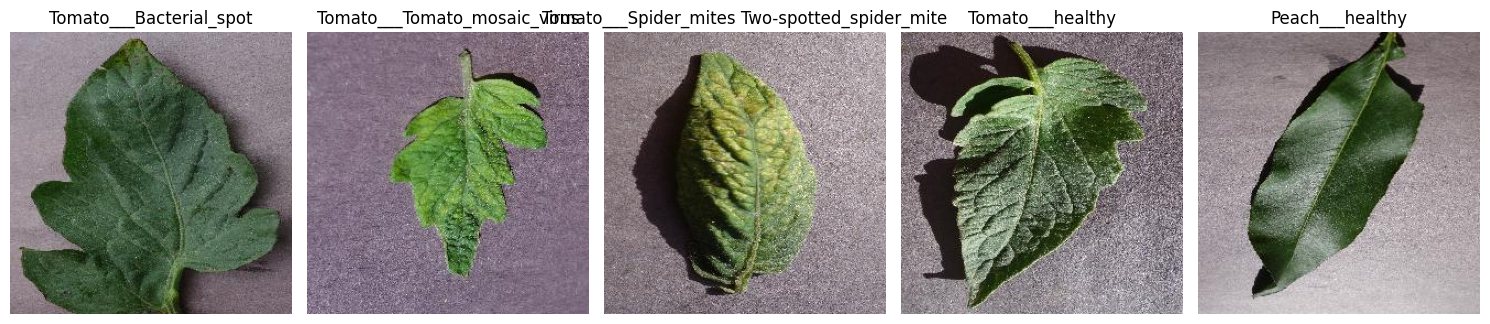

In [81]:
# Plotting some random images.
random_classes = random.sample(diseases, 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, disease in enumerate(random_classes):
    class_dir = os.path.join(train_dir, disease)
    image_name = random.choice(os.listdir(class_dir))
    image_path = os.path.join(class_dir, image_name)

    img = Image.open(image_path)
    axes[i].imshow(img)
    axes[i].set_title(disease)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [82]:
# Total Number of Plants
plants = []
NumDiseases = 0
for plant in diseases:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
    if plant.split('___')[1] != 'healthy':
        NumDiseases += 1


print(f"Number of Plants: {plants}\n\n")
print(f"Number of Diseases: {NumDiseases}\n\n")
print(f"Number of Unique Plants: {len(plants)}")

Number of Plants: ['Strawberry', 'Grape', 'Potato', 'Blueberry', 'Corn_(maize)', 'Tomato', 'Peach', 'Pepper,_bell', 'Orange', 'Cherry_(including_sour)', 'Apple', 'Raspberry', 'Squash', 'Soybean']


Number of Diseases: 26


Number of Unique Plants: 14


In [83]:
# Count the number of images per class
nums = {disease: len(os.listdir(os.path.join(train_dir, disease))) for disease in diseases}

# Convert to DataFrame
img_per_class = pd.DataFrame(list(nums.items()), columns=["Class Name", "No. of Images"])

# Sort values for better visualization
img_per_class = img_per_class.sort_values(by="No. of Images", ascending=False)
img_per_class

,Class Name,No. of Images
37,Soybean___healthy,2022
25,Apple___Apple_scab,2016
11,Orange___Haunglongbing_(Citrus_greening),2010
34,Apple___healthy,2008
10,"Pepper,_bell___healthy",1988
33,Apple___Black_rot,1987
24,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961
2,Potato___Early_blight,1939
7,Potato___Late_blight,1939
22,Tomato___healthy,1926


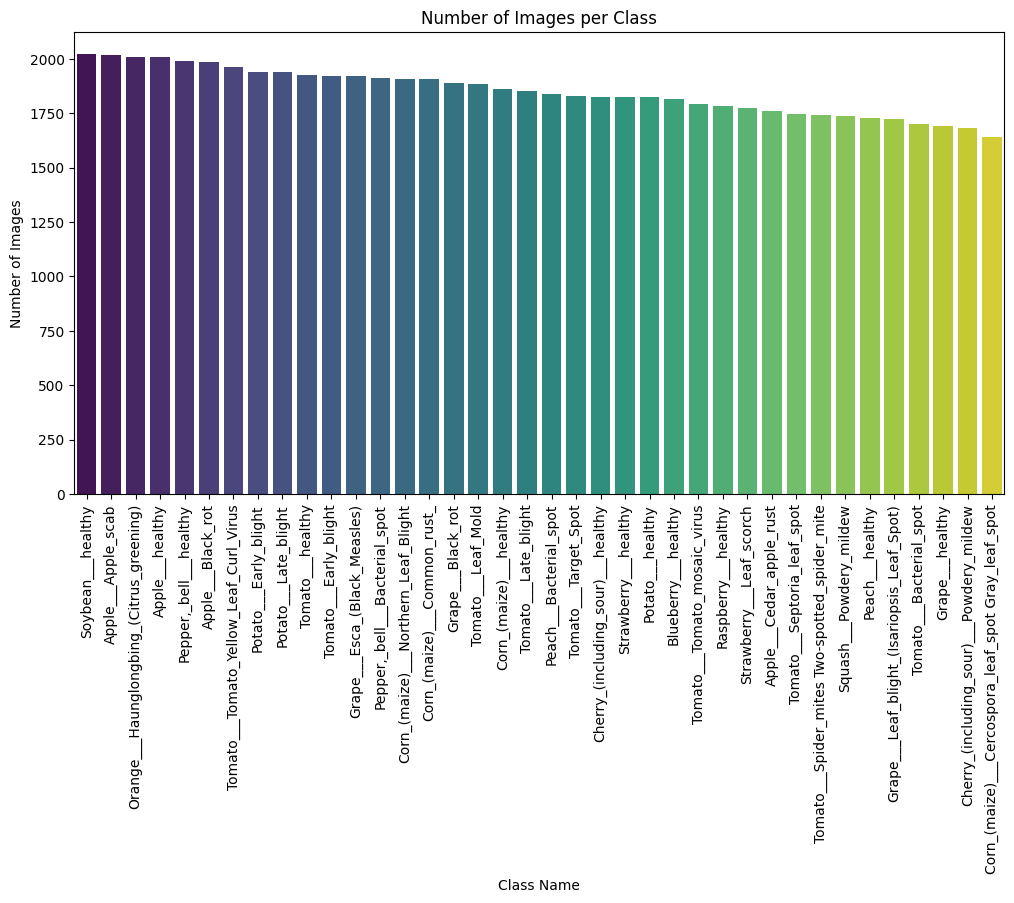

In [84]:
# Visualizing the information graph.
# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x="Class Name", y="No. of Images", data=img_per_class, palette="viridis")
plt.xticks(rotation=90)  # Rotate class names for better readability
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")
plt.show()

## Data Preprocessing

### Setting and Loading Images for training

`ImageFolder` is a PyTorch dataset class `(torchvision.datasets.ImageFolder)` used to load image datasets structured in a folder format.

- Allow you to access images as tensors.
- Assign numerical labels based on folder names.
- Can be used with a DataLoader for batching and shuffling.

In [85]:
train = ImageFolder(train_dir, transform=transforms.ToTensor())
valid = ImageFolder(valid_dir, transform=transforms.ToTensor())

In [86]:
img, label = train[1]
print(f"Image Shape: {img.shape}\nClass Name: {label}")

Image Shape: torch.Size([3, 256, 256])
Class Name: 0


In [87]:
random_seed = 42
BATCH_SIZE = 32
torch.manual_seed(random_seed)

`train_dataloader` and `valid_dataloader`: 
- Load images in batches for training & validation.
- Improve efficiency with parallel data loading (num_workers=2).
- Optimize GPU performance with pin_memory=True.

In [88]:
# DataLoaders for training and validation
train_dataloader = DataLoader(train, BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_dataloader = DataLoader(valid, BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

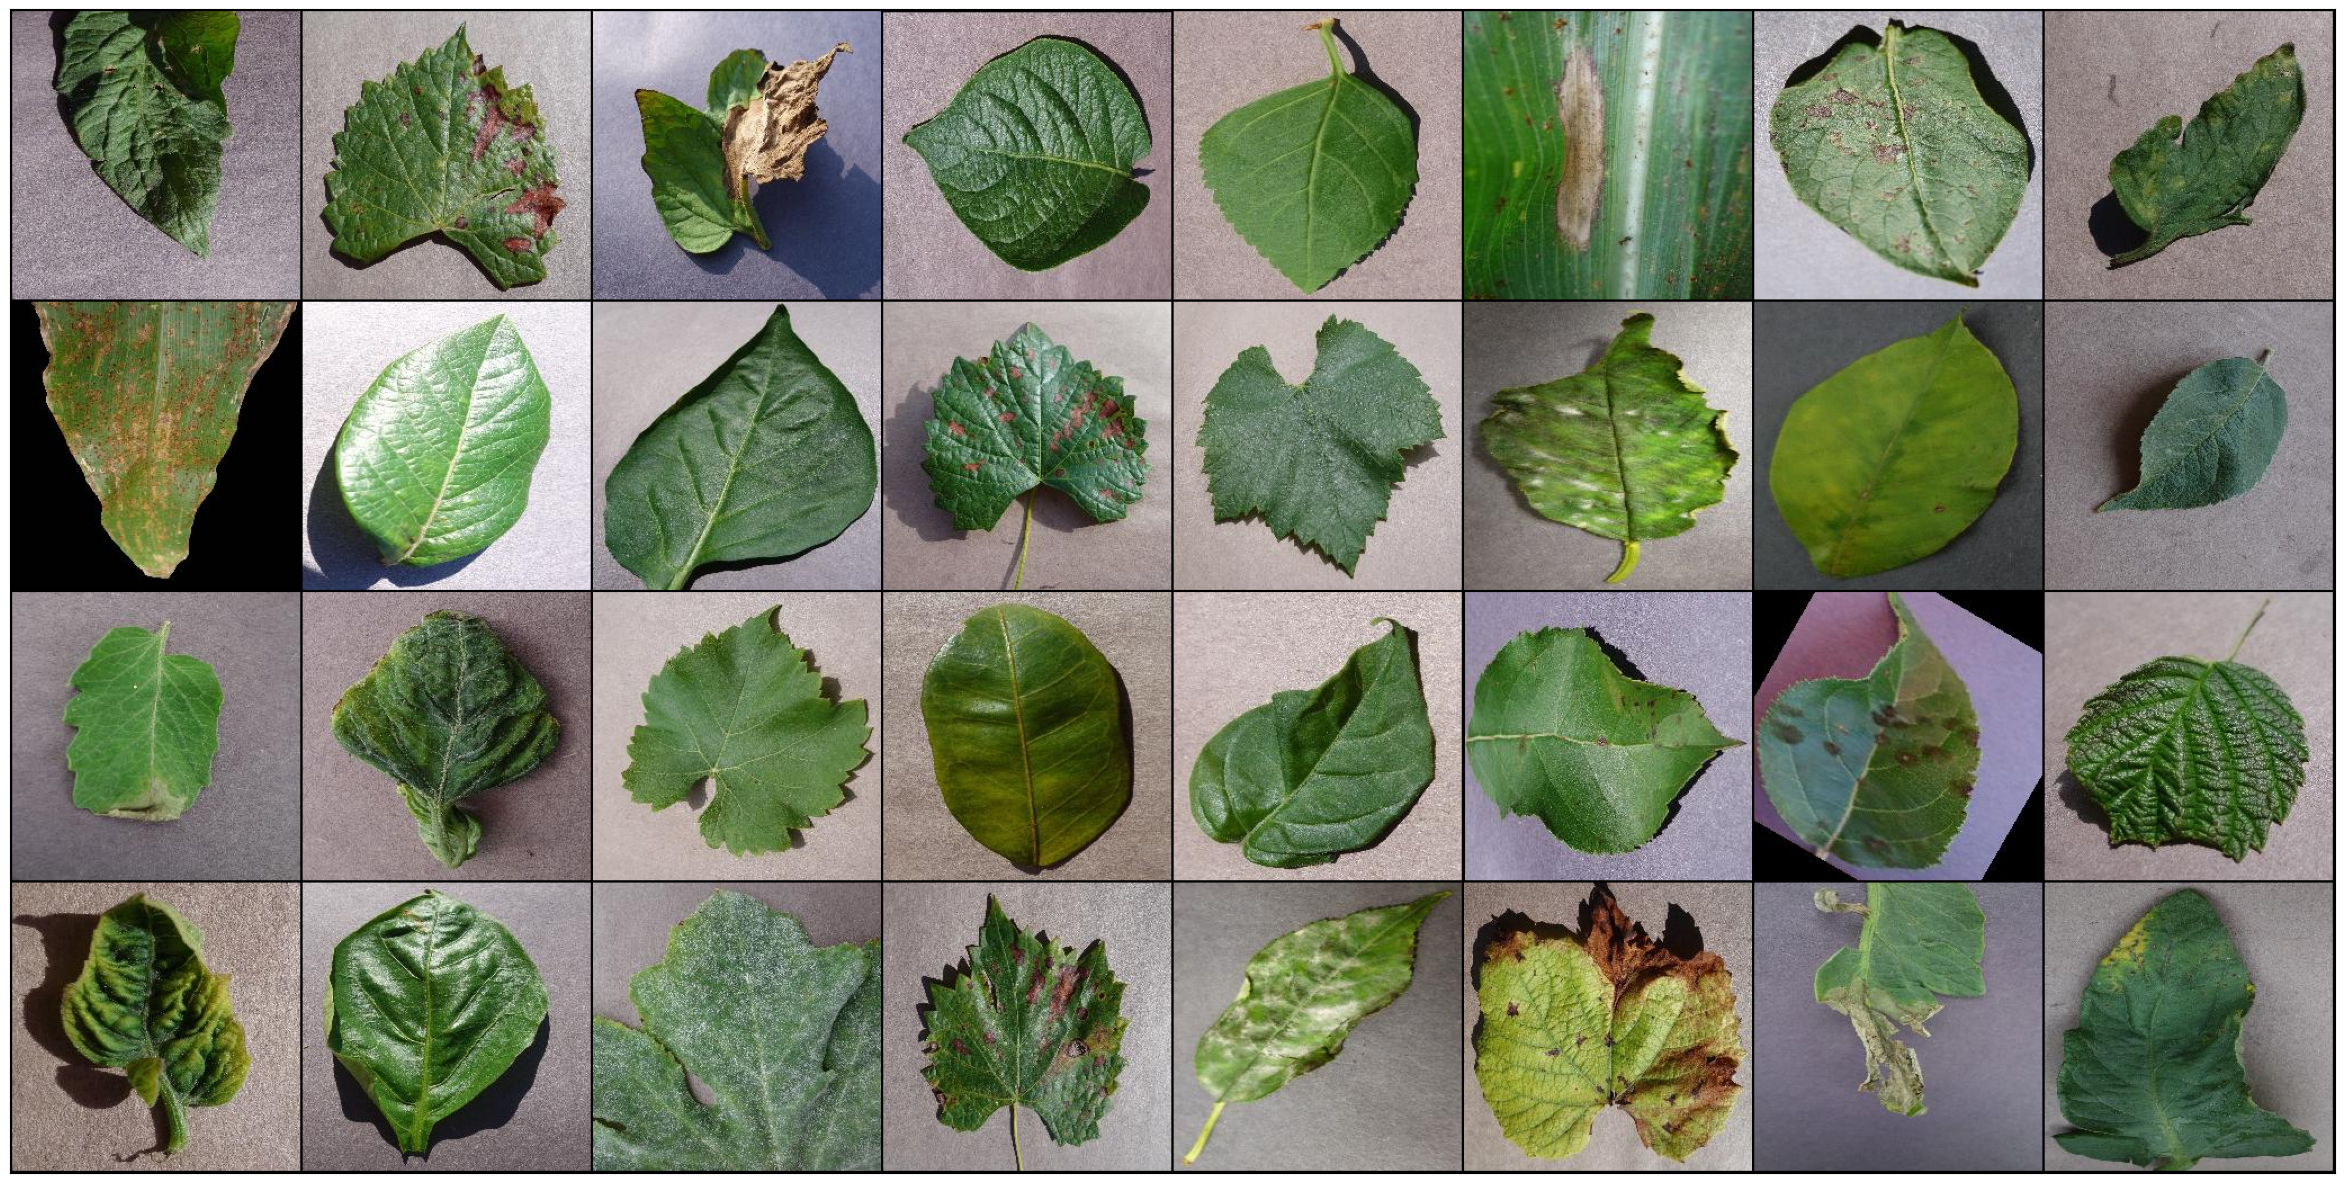

In [89]:
def showImageBatches(data):
    for images, labels in data:
        fig, ax = plt.subplots(figsize=(30, 30))
        ax.set_xticks([]);
        ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=8).permute(1, 2, 0))
        break


showImageBatches(train_dataloader)

In [90]:
print(f"Train DataLoader: {len(train_dataloader)}\nValid DataLoader: {len(valid_dataloader)}")

Train DataLoader: 2197
Valid DataLoader: 550


In [91]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 256, 256]), torch.Size([32]))

Image Size: torch.Size([256, 256, 3])
Label: 3
Label Size: torch.Size([])


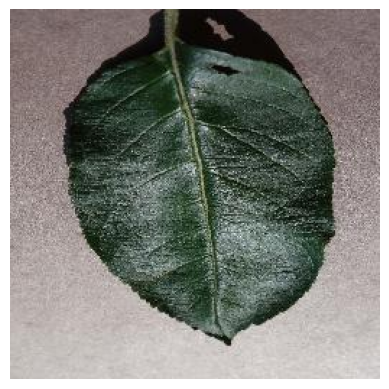

In [92]:
# Showing a sample

# Randomly select an index
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()

# Get image and label
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

# Convert image from (C, H, W) -> (H, W, C) for Matplotlib
img = img.permute(1, 2, 0)

# Plot the image
plt.imshow(img)  # Removed cmap="gray" since it's an RGB image]
plt.axis(False)

# Print details
print(f"Image Size: {img.shape}")  # Now (H, W, C)
print(f"Label: {label}\nLabel Size: {label.shape}")

### Setting Up Helper Functions for Computing

In [93]:
# for moving data into GPU (if available)
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

# for moving data to device (CPU or GPU)
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

# for loading in the device (GPU if available else CPU)
class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [94]:
device = get_default_device()
device

device(type='mps')

In [95]:
# Move Train and Valid DataLoaders to the Device
train_dataloader = DeviceDataLoader(train_dataloader, device)
valid_dataloader = DeviceDataLoader(valid_dataloader, device)

## Building Model.

In [96]:
# %pip install torchcam
# %pip install git+https://github.com/jacobgil/pytorch-grad-cam.git

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# %pip install shap
import shap
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from tqdm import tqdm

### Functionizing Train, Validate, GradCAM, SHAP

In [98]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, grad_clip=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in tqdm(train_loader, desc='Training'):  # Added tqdm
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        if grad_clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        optimizer.step()
        total_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(train_loader), correct / total

In [99]:
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validating'):  # Added tqdm
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(val_loader), correct / total, all_preds, all_labels

In [100]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=10, grad_clip=1.0):
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, grad_clip)
        val_loss, val_acc, all_preds, all_labels = validate(model, val_loader, criterion, device)
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}\n")
    
    return model, all_preds, all_labels

In [101]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


In [102]:
def gradcam_visualization(model, image, target_layer, device):
    cam = GradCAM(model=model, target_layers=[target_layer])
    input_tensor = image.unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(0)])
    grayscale_cam = grayscale_cam[0, :]
    
    image_np = image.permute(1, 2, 0).cpu().numpy()
    visualization = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)
    plt.imshow(visualization)
    plt.show()

In [103]:
def shap_explainability(model, dataloader, device, num_samples=5):
    model.eval()
    
    batch = next(iter(dataloader))
    images, _ = batch
    images = images[:num_samples].to(device)  # Take a smaller subset
    
    explainer = shap.GradientExplainer(model, images)
    shap_values = explainer.shap_values(images)

    shap.image_plot(shap_values, images.cpu().numpy())

In [104]:
# Model Setup
model1 = models.resnet50(pretrained=False, num_classes=38)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model1.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [105]:
# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

In [106]:
# Training
model1, all_preds, all_labels = train_model(model1, train_dataloader,
                                           valid_dataloader, criterion,
                                           optimizer, scheduler, device, epochs=2, grad_clip=1.0)

Training:   1%|          | 15/2197 [06:13<14:29:34, 23.91s/it]

: 

Train for more epochs you will get more accuracy, precision, and F1 Score.

## Evaluation

In [68]:
#Classification Report
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(38)]))

              precision    recall  f1-score   support

           0       0.94      0.82      0.88       504
           1       0.97      0.68      0.80       497
           2       0.80      0.91      0.85       440
           3       0.71      0.89      0.79       502
           4       0.91      0.51      0.65       454
           5       0.96      0.84      0.89       421
           6       0.97      0.37      0.54       456
           7       0.60      0.93      0.73       410
           8       1.00      0.96      0.98       477
           9       0.91      0.50      0.65       477
          10       0.97      1.00      0.98       465
          11       0.92      0.63      0.75       472
          12       0.73      0.99      0.84       480
          13       0.82      0.97      0.89       430
          14       0.65      0.96      0.78       423
          15       0.98      0.88      0.93       503
          16       0.88      0.89      0.89       459
          17       0.97    

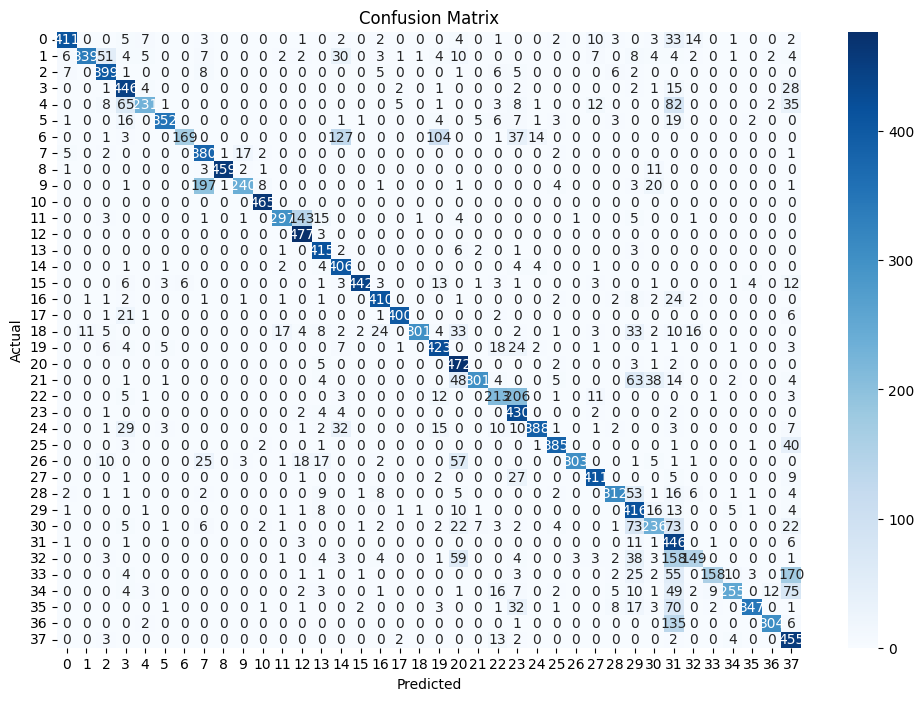

In [69]:
# Confusion Matrix
plot_confusion_matrix(all_labels, all_preds, class_names=[str(i) for i in range(38)])

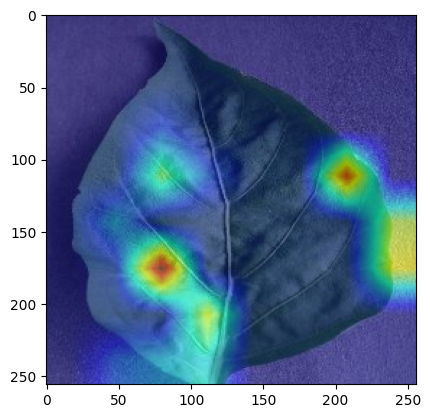

In [70]:
# GradCAM Example
image, _ = next(iter(valid_dataloader))
gradcam_visualization(model1, image[0], model1.layer4[2], device)

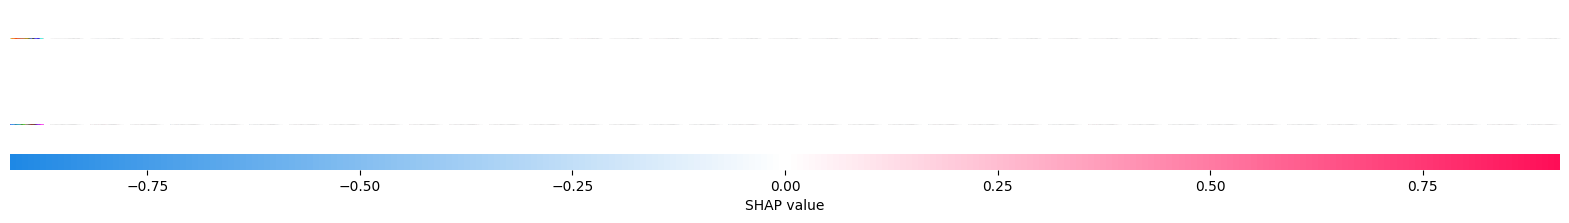

In [73]:
# SHAP Explainability
shap_explainability(model1, valid_dataloader, device)

## Testing Model On Test Data

In [76]:
test_dir = "../input/new-plant-diseases-dataset/test"
test = ImageFolder(test_dir, transform=transforms.ToTensor())

In [ ]:
test_images = sorted(os.listdir(test_dir + '/test')) # since images in test folder are in alphabetical order
test_images

In [ ]:
def predict_image(img, model):
    """Converts image to array and return the predicted class
        with highest probability"""
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model1(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label

    return train.classes[preds[0].item()]

In [ ]:
# predicting first image
img, label = test[0]
plt.imshow(img.permute(1, 2, 0))
print('Label:', test_images[0], ', Predicted:', predict_image(img, model1))

In [ ]:
# getting all predictions (actual label vs predicted)
for i, (img, label) in enumerate(test):
    print('Label:', test_images[i], ', Predicted:', predict_image(img, model1))

## Save model.

In [ ]:
# saving the entire model to working directory
PATH = '/kaggle/working/plant-disease-model-complete.pth'
torch.save(model, PATH)